# 09 Explainability and SHAP

## Purpose
Explain model predictions using feature importance and SHAP when the optional `shap` package is available.

## Imports

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "models"
for directory in [FIGURES_DIR, TABLES_DIR, MODELS_DIR, DATA_DIR / "processed"]:
    directory.mkdir(parents=True, exist_ok=True)

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.features import get_modeling_matrices
from src.visualization import plot_feature_importance, get_feature_names_from_pipeline

## Data loading

In [2]:
feature_df = pd.read_csv(DATA_DIR / "processed" / "modeling_dataset.csv")
at_risk_df = feature_df[feature_df["baseline_condition_count"] < 2].copy()
model_candidates = [
    MODELS_DIR / "multimorbidity_progression_lightgbm.joblib",
    MODELS_DIR / "multimorbidity_progression_xgboost.joblib",
    MODELS_DIR / "multimorbidity_progression_random_forest.joblib",
]
model_path = next((path for path in model_candidates if path.exists()), None)
if model_path is None:
    raise FileNotFoundError("Run notebook 07 first to save a fitted progression model.")
model = joblib.load(model_path)
model_path

PosixPath('/Users/chinmaynaringrekar/PythonProject/Disease Progression and Multimorbidity Prediction/models/multimorbidity_progression_random_forest.joblib')

## Main explainability

,feature,importance
66,numeric__medication_indication_count,0.133057
65,numeric__medication_unique_count,0.087624
64,numeric__medication_count,0.077635
9,numeric__baseline_visit_type_count,0.036891
69,numeric__medication_generic_rate,0.035407
7,numeric__baseline_condition_count,0.035145
10,numeric__baseline_specialty_count,0.032762
0,numeric__age,0.030037
8,numeric__baseline_visit_count,0.029863
6,numeric__charlson_index,0.019046


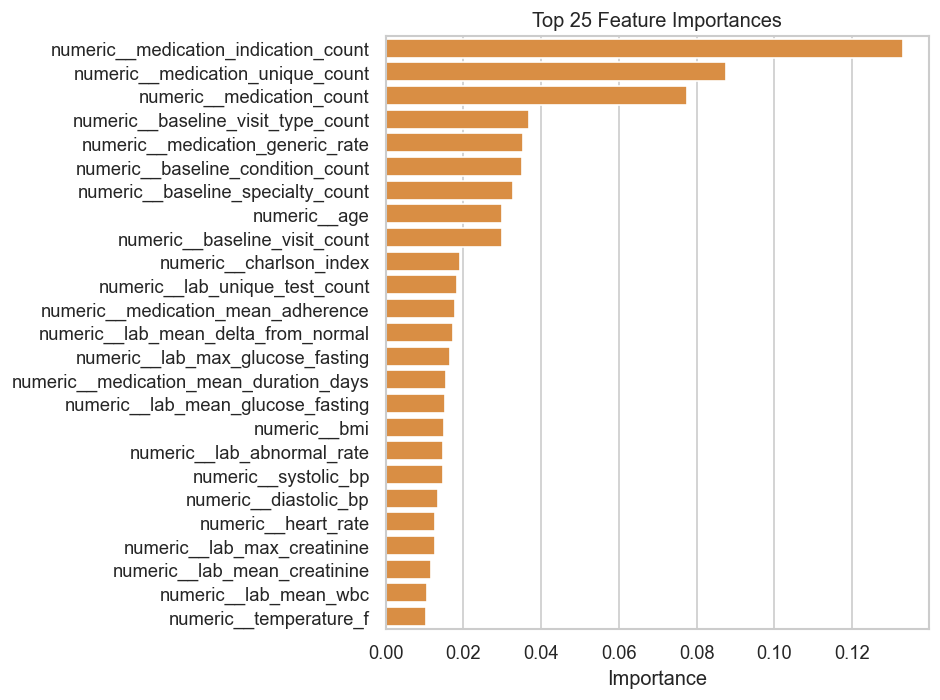

In [3]:
fig, ax, importance = plot_feature_importance(
    model,
    top_n=25,
    path=FIGURES_DIR / "09_model_feature_importance.png",
)
importance.head(25)

In [4]:
# Optional SHAP explanation. If shap is not installed, the feature importance above still satisfies explainability.
try:
    import shap

    X, y = get_modeling_matrices(at_risk_df, "multimorbidity_progression")
    _, X_sample, _, _ = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)
    X_sample = X_sample.head(500)

    transformed = model.named_steps["preprocess"].transform(X_sample)
    feature_names = get_feature_names_from_pipeline(model)
    estimator = model.named_steps["model"]

    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(transformed)
    values = shap_values[1] if isinstance(shap_values, list) else shap_values

    shap.summary_plot(values, transformed, feature_names=feature_names, show=False, max_display=20)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "09_shap_summary.png", dpi=150, bbox_inches="tight")
    shap_available = True
except Exception as exc:
    shap_available = False
    print("SHAP was not run:", exc)

SHAP was not run: No module named 'shap'


## Key findings

- Feature importance identifies the strongest model inputs for predicted progression.
- SHAP, when available, adds patient-level directional explanations for the tree model.
- These outputs are useful in the final report's technical approach and findings sections.

## Saved outputs

In [5]:
importance.to_csv(TABLES_DIR / "09_feature_importance.csv", index=False)
print("SHAP available:", shap_available)
print("Saved explainability outputs.")

SHAP available: False
Saved explainability outputs.
